# exp002: 北木島（岡山県笠岡市）丁場水域検出

## 概要

Sentinel-2衛星画像の水域指数を用いて、北木島の丁場（石切場跡）に溜まった水域を検出し、インタラクティブ地図で可視化する。

### 手法

- **データソース**: Sentinel-2 L2A（Microsoft Planetary Computer経由）
- **水域指数**（2種を併用し、和集合で検出感度を向上）:
  - **NDWI** = (Green − NIR) / (Green + NIR) — Band 3 (560nm) / Band 8 (842nm)
  - **MNDWI** = (Green − SWIR) / (Green + SWIR) — Band 3 (560nm) / Band 11 (1610nm)
- MNDWI は岩肌・裸地と水域の分離能力が NDWI より高い（Xu, 2006）
- **可視化**: Folium（Leaflet.js）によるインタラクティブ地図

### 北木島について

北木島は岡山県笠岡市に属する笠岡諸島最大の島。花崗岩（北木石）の産地として知られ、かつて多数の丁場（採石場）が稼働していた。閉鎖後の丁場跡には雨水が溜まり、池状の水域を形成している。これらの水域を衛星画像から検出することで、丁場の位置を把握する。

In [1]:
# 依存パッケージはpyproject.tomlで管理済み（uv add で追加済み）
# プロジェクトルートで `uv run jupyter notebook` で起動すれば全パッケージが利用可能

In [2]:
import numpy as np
import rasterio
import rasterio.transform
from rasterio.warp import transform_bounds, transform_geom, reproject, calculate_default_transform
from rasterio.windows import from_bounds
from rasterio.features import shapes as rasterio_shapes
from rasterio.enums import Resampling
from rasterio.transform import from_bounds as transform_from_bounds
from rasterio.crs import CRS
import pystac_client
import planetary_computer
import folium
from folium.raster_layers import ImageOverlay
import matplotlib.pyplot as plt
from PIL import Image
from shapely.geometry import shape as shapely_shape
import io
import base64
import json
import os

## 1. 対象地域の定義

北木島の範囲をバウンディングボックスで定義する。

In [3]:
# 北木島の中心座標と範囲
KITAGI_CENTER = [34.374, 133.543]  # [lat, lon]
KITAGI_BBOX = [133.515, 34.350, 133.570, 34.400]  # [west, south, east, north]

# 水域判定閾値（丁場の小規模水域を拾うため低めに設定）
NDWI_THRESHOLD = -0.2    # NDWI判定閾値
MNDWI_THRESHOLD = -0.1   # MNDWI判定閾値（SWIRは岩肌との分離が良い）

# NDVI植生マスク閾値（夏季画像で効果的）
NDVI_VEG_THRESHOLD = 0.3  # NDVI > 0.3 の植生を水域候補から除外

# 検索パラメータ
SEARCH_DATETIME = "2023-01-01/2025-12-31"
MAX_CLOUD_COVER = 10  # 最大雲量 (%)
PREFERRED_MONTHS = [6, 7, 8, 9]  # 夏季を優先（植生が豊富で水域との分離が容易）

# 水域ポリゴン最小面積（小さな丁場の水溜りも拾う）
MIN_AREA_M2 = 100  # m²

# 出力ディレクトリ
OUTPUT_DIR = "../tmp"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Sentinel-2画像の検索

Microsoft Planetary ComputerのSTAC APIを用いて、対象地域・期間の雲量の少ないSentinel-2 L2A画像を検索する。

In [4]:
# STAC APIカタログに接続
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Sentinel-2 L2A画像を検索
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=KITAGI_BBOX,
    datetime=SEARCH_DATETIME,
    query={"eo:cloud_cover": {"lt": MAX_CLOUD_COVER}},
    sortby=[{"field": "properties.eo:cloud_cover", "direction": "asc"}],
    max_items=50,
)

items = list(search.items())
print(f"検索結果: {len(items)} シーン\n")

# 夏季画像をフィルタ
summer_items = [item for item in items if item.datetime.month in PREFERRED_MONTHS]
print(f"夏季画像（{PREFERRED_MONTHS}月）: {len(summer_items)} シーン")
for item in summer_items[:10]:
    cc = item.properties["eo:cloud_cover"]
    dt = item.datetime.strftime("%Y-%m-%d")
    print(f"  {item.id}: 雲量={cc:.1f}%, 撮影日={dt}")

# 夏季画像があればそこから選択、なければ全期間から選択
if summer_items:
    selected_item = summer_items[0]
    print(f"\n→ 夏季画像から選択")
else:
    selected_item = items[0]
    print(f"\n→ 夏季画像なし、全期間から選択")

print(f"\n--- 選択画像 ---")
print(f"  ID: {selected_item.id}")
print(f"  撮影日: {selected_item.datetime.strftime('%Y-%m-%d')}")
print(f"  雲量: {selected_item.properties['eo:cloud_cover']:.1f}%")

# 利用可能なバンドを確認
print(f"\n利用可能なアセット:")
for key in sorted(selected_item.assets.keys()):
    if key.startswith("B"):
        print(f"  {key}: {selected_item.assets[key].title}")

検索結果: 33 シーン

夏季画像（[6, 7, 8, 9]月）: 2 シーン
  S2A_MSIL2A_20250802T015121_R017_T53SLU_20250802T044417: 雲量=0.7%, 撮影日=2025-08-02
  S2C_MSIL2A_20250601T014711_R017_T53SLU_20250601T045516: 雲量=8.3%, 撮影日=2025-06-01

→ 夏季画像から選択

--- 選択画像 ---
  ID: S2A_MSIL2A_20250802T015121_R017_T53SLU_20250802T044417
  撮影日: 2025-08-02
  雲量: 0.7%

利用可能なアセット:
  B01: Band 1 - Coastal aerosol - 60m
  B02: Band 2 - Blue - 10m
  B03: Band 3 - Green - 10m
  B04: Band 4 - Red - 10m
  B05: Band 5 - Vegetation red edge 1 - 20m
  B06: Band 6 - Vegetation red edge 2 - 20m
  B07: Band 7 - Vegetation red edge 3 - 20m
  B08: Band 8 - NIR - 10m
  B09: Band 9 - Water vapor - 60m
  B11: Band 11 - SWIR (1.6) - 20m
  B12: Band 12 - SWIR (2.2) - 20m
  B8A: Band 8A - Vegetation red edge 4 - 20m


## 3. バンドデータの読み込みと水域指数計算

Green (B03)、Red (B04)、NIR (B08)、SWIR (B11) バンドを読み込み、3種の指数を計算する。

- **NDWI = (Green − NIR) / (Green + NIR)** — 標準的な水域指数
- **MNDWI = (Green − SWIR) / (Green + SWIR)** — 岩肌・裸地と水域の分離に優れる
- **NDVI = (NIR − Red) / (NIR + Red)** — 植生指数（植生除外マスク用）

B11（SWIR、20m分解能）は B03/B08（10m分解能）に合わせてバイリニア補間でリサンプリングする。

水域判定: **(NDWI超 OR MNDWI超) AND NDVI < 植生閾値** の複合判定で、植生の誤検出を排除する。

In [5]:
def read_band_aoi(asset_href, bbox, target_shape=None):
    """
    指定バウンディングボックス範囲のバンドデータを読み込む。
    target_shape を指定すると、そのサイズにリサンプリングする（低解像度バンド用）。

    Returns:
        data: バンドデータ (float32)
        bounds_4326: 実際の読み込み範囲 [west, south, east, north] (EPSG:4326)
        win_transform: ウィンドウのアフィン変換
        crs: 座標参照系
    """
    with rasterio.open(asset_href) as src:
        bounds_native = transform_bounds("EPSG:4326", src.crs, *bbox)
        window = from_bounds(*bounds_native, src.transform)

        if target_shape is not None:
            data = src.read(
                1, window=window,
                out_shape=target_shape,
                resampling=Resampling.bilinear,
            ).astype(np.float32)
        else:
            data = src.read(1, window=window).astype(np.float32)

        actual_bounds = rasterio.windows.bounds(window, src.transform)
        bounds_4326 = transform_bounds(src.crs, "EPSG:4326", *actual_bounds)

        if target_shape is not None:
            win_transform = transform_from_bounds(
                *actual_bounds, target_shape[1], target_shape[0]
            )
        else:
            win_transform = src.window_transform(window)

        return data, bounds_4326, win_transform, src.crs


# --- 10mバンド: Green (B03), Red (B04), NIR (B08) ---
print("Green (B03) バンドを読み込み中...")
green, bounds_4326, win_transform, crs = read_band_aoi(
    selected_item.assets["B03"].href, KITAGI_BBOX
)
ref_shape = green.shape

print("Red (B04) バンドを読み込み中...")
red, _, _, _ = read_band_aoi(selected_item.assets["B04"].href, KITAGI_BBOX)

print("NIR (B08) バンドを読み込み中...")
nir, _, _, _ = read_band_aoi(selected_item.assets["B08"].href, KITAGI_BBOX)

# --- 20mバンド: SWIR (B11) → 10mにリサンプリング ---
print("SWIR (B11) バンドを読み込み中（20m → 10mリサンプリング）...")
swir, _, _, _ = read_band_aoi(
    selected_item.assets["B11"].href, KITAGI_BBOX, target_shape=ref_shape
)

print(f"\nバンドサイズ: {green.shape} (rows x cols)")
print(f"座標参照系: {crs}")
print(f"撮影日: {selected_item.datetime.strftime('%Y-%m-%d')}")

# --- NDWI ---
ndwi = np.where((green + nir) > 0, (green - nir) / (green + nir), 0)

# --- MNDWI ---
mndwi = np.where((green + swir) > 0, (green - swir) / (green + swir), 0)

# --- NDVI（植生マスク用）---
ndvi = np.where((nir + red) > 0, (nir - red) / (nir + red), 0)
veg_mask = ndvi > NDVI_VEG_THRESHOLD

# --- 複合水域マスク: (水域指数超) AND (植生でない) ---
water_candidates = (ndwi > NDWI_THRESHOLD) | (mndwi > MNDWI_THRESHOLD)
water_mask = water_candidates & ~veg_mask

# 複合水域スコア（可視化用）
water_score = np.maximum(ndwi, mndwi)

print(f"\n--- 検出結果 ---")
print(f"NDWI  値域: [{ndwi.min():.3f}, {ndwi.max():.3f}]")
print(f"MNDWI 値域: [{mndwi.min():.3f}, {mndwi.max():.3f}]")
print(f"NDVI  値域: [{ndvi.min():.3f}, {ndvi.max():.3f}]")
print(f"水域候補 (NDWI超 | MNDWI超):  {water_candidates.sum():,} px")
print(f"植生マスク (NDVI > {NDVI_VEG_THRESHOLD}): {veg_mask.sum():,} px")
print(f"最終水域マスク (候補 & ~植生): {water_mask.sum():,} px")
print(f"植生マスクで除外されたピクセル: {(water_candidates & veg_mask).sum():,} px")

Green (B03) バンドを読み込み中...
Red (B04) バンドを読み込み中...
NIR (B08) バンドを読み込み中...
SWIR (B11) バンドを読み込み中（20m → 10mリサンプリング）...

バンドサイズ: (562, 514) (rows x cols)
座標参照系: EPSG:32653
撮影日: 2025-08-02

--- 検出結果 ---
NDWI  値域: [-0.632, 0.210]
MNDWI 値域: [-0.434, 0.438]
NDVI  値域: [-0.231, 0.698]
水域候補 (NDWI超 | MNDWI超):  212,803 px
植生マスク (NDVI > 0.3): 72,636 px
最終水域マスク (候補 & ~植生): 212,794 px
植生マスクで除外されたピクセル: 9 px


## 4. 静的可視化

NDWI・MNDWI・複合水域スコアの空間分布を確認する。青系が水域を示す。

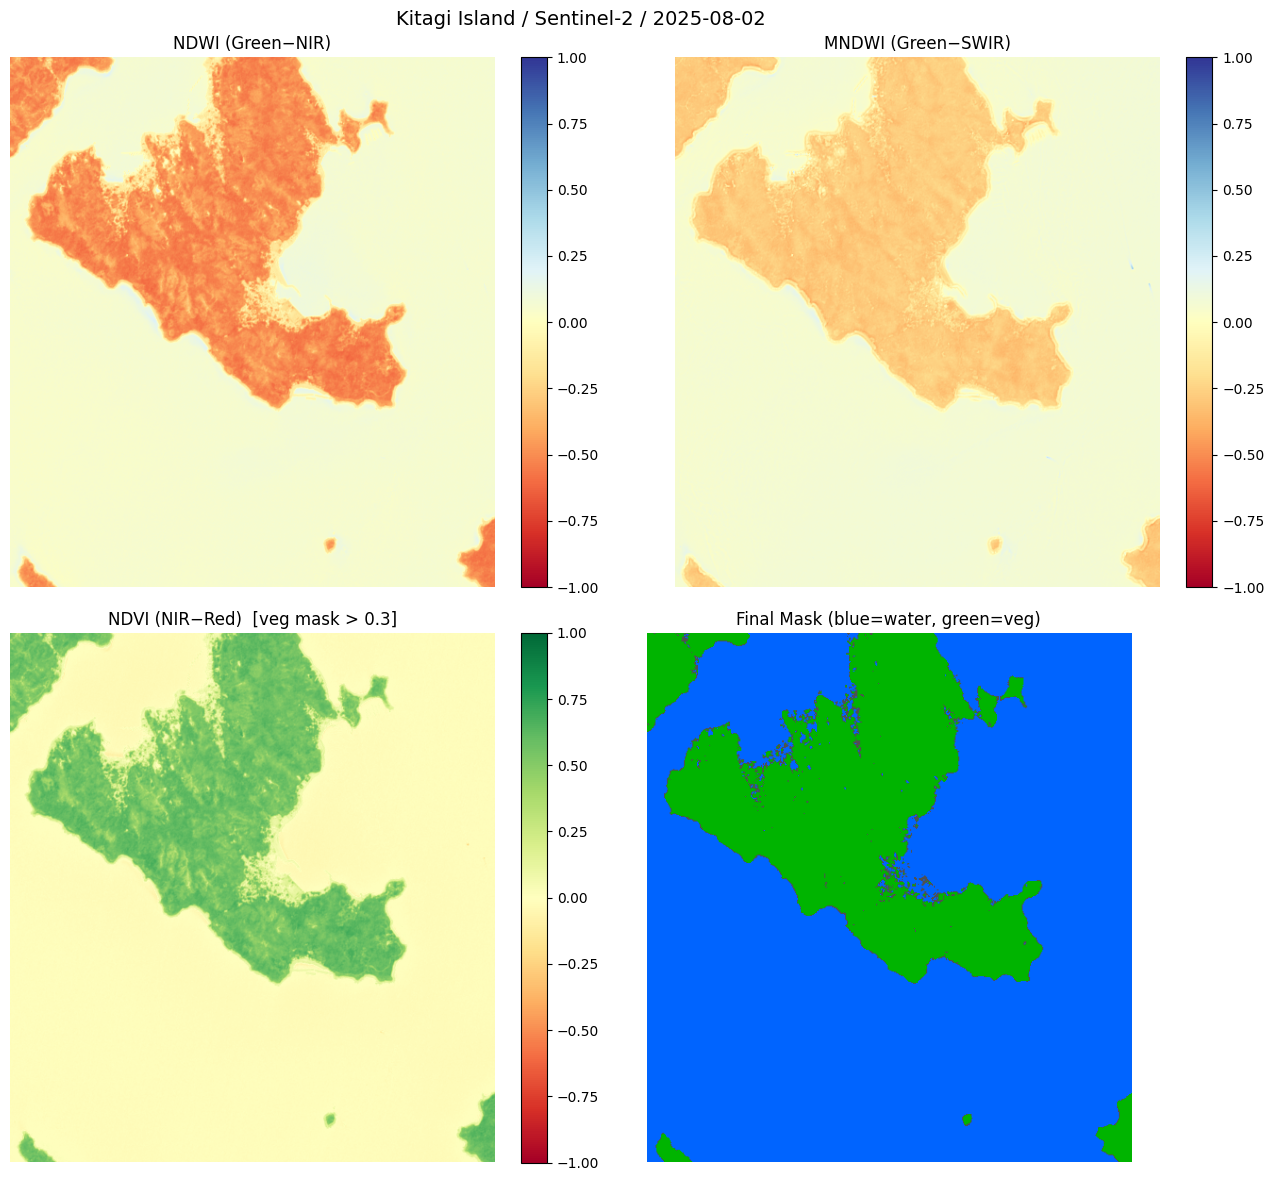

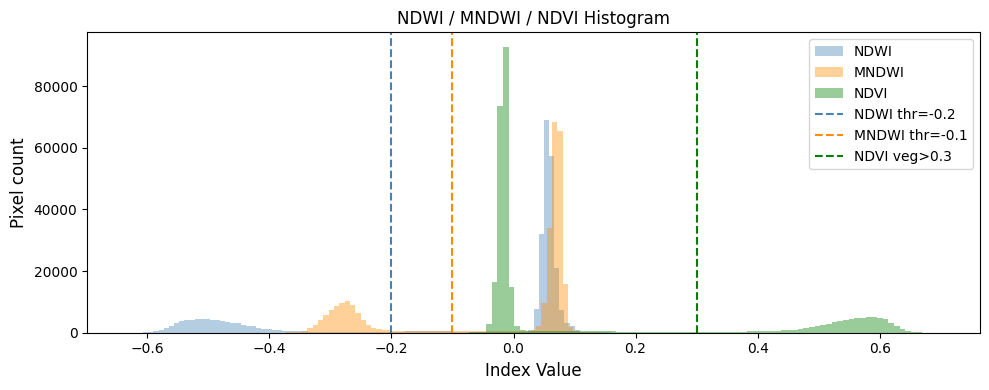

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# NDWI
im0 = axes[0, 0].imshow(ndwi, cmap="RdYlBu", vmin=-1, vmax=1)
axes[0, 0].set_title("NDWI (Green−NIR)", fontsize=12)
axes[0, 0].axis("off")
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

# MNDWI
im1 = axes[0, 1].imshow(mndwi, cmap="RdYlBu", vmin=-1, vmax=1)
axes[0, 1].set_title("MNDWI (Green−SWIR)", fontsize=12)
axes[0, 1].axis("off")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

# NDVI
im2 = axes[1, 0].imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
axes[1, 0].set_title(f"NDVI (NIR−Red)  [veg mask > {NDVI_VEG_THRESHOLD}]", fontsize=12)
axes[1, 0].axis("off")
plt.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04)

# 最終水域マスク
mask_rgb = np.zeros((*water_mask.shape, 3), dtype=np.uint8)
mask_rgb[water_mask] = [0, 100, 255]       # 水域: 青
mask_rgb[veg_mask] = [0, 180, 0]           # 植生: 緑
mask_rgb[~water_mask & ~veg_mask] = [80, 80, 80]  # その他: グレー
axes[1, 1].imshow(mask_rgb)
axes[1, 1].set_title("Final Mask (blue=water, green=veg)", fontsize=12)
axes[1, 1].axis("off")

date_str = selected_item.datetime.strftime("%Y-%m-%d")
plt.suptitle(f"Kitagi Island / Sentinel-2 / {date_str}", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/exp002_ndwi_static.png", dpi=150, bbox_inches="tight")
plt.show()

# ヒストグラム比較
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ndwi.ravel(), bins=100, alpha=0.4, label="NDWI", color="steelblue")
ax.hist(mndwi.ravel(), bins=100, alpha=0.4, label="MNDWI", color="darkorange")
ax.hist(ndvi.ravel(), bins=100, alpha=0.4, label="NDVI", color="green")
ax.axvline(x=NDWI_THRESHOLD, color="steelblue", linestyle="--", label=f"NDWI thr={NDWI_THRESHOLD}")
ax.axvline(x=MNDWI_THRESHOLD, color="darkorange", linestyle="--", label=f"MNDWI thr={MNDWI_THRESHOLD}")
ax.axvline(x=NDVI_VEG_THRESHOLD, color="green", linestyle="--", label=f"NDVI veg>{NDVI_VEG_THRESHOLD}")
ax.set_xlabel("Index Value", fontsize=12)
ax.set_ylabel("Pixel count", fontsize=12)
ax.set_title("NDWI / MNDWI / NDVI Histogram", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/exp002_ndwi_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. GeoTIFF出力

水域指数ラスタおよび水域を強調したトゥルーカラー合成画像をGeoTIFFとして保存する。

- **水域指数 GeoTIFF**: NDWI・MNDWI・NDVI・water_score の4バンド（float32）
- **水域強調画像 GeoTIFF**: トゥルーカラー（B04/B03/B02）に複合水域マスクを青色で強調重畳（RGBA、4バンド）

水域指数 GeoTIFF: ../tmp/exp002_kitagi_ndwi.tif
Blue (B02) バンドを読み込み中...
水域強調画像 GeoTIFF: ../tmp/exp002_kitagi_water_highlighted.tif


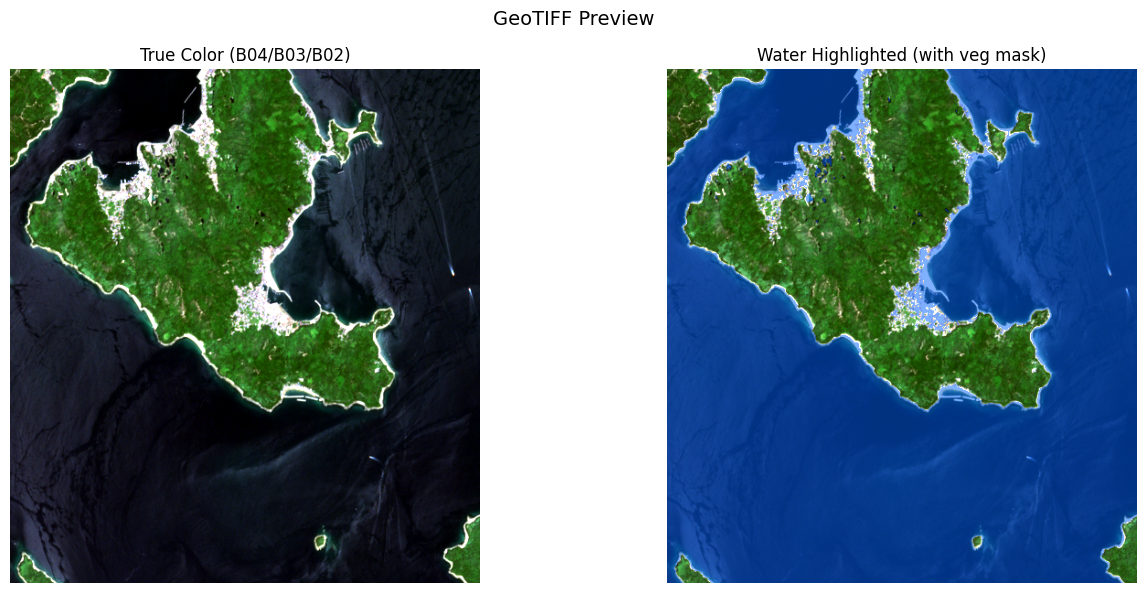

In [7]:
# --- 1) 水域指数 GeoTIFF（4バンド: NDWI, MNDWI, NDVI, water_score）---
ndwi_tiff_path = f"{OUTPUT_DIR}/exp002_kitagi_ndwi.tif"
with rasterio.open(
    ndwi_tiff_path,
    "w",
    driver="GTiff",
    height=ndwi.shape[0],
    width=ndwi.shape[1],
    count=4,
    dtype="float32",
    crs=crs,
    transform=win_transform,
) as dst:
    dst.write(ndwi, 1)
    dst.write(mndwi, 2)
    dst.write(ndvi, 3)
    dst.write(water_score, 4)
    dst.set_band_description(1, "NDWI")
    dst.set_band_description(2, "MNDWI")
    dst.set_band_description(3, "NDVI")
    dst.set_band_description(4, "WaterScore")
print(f"水域指数 GeoTIFF: {ndwi_tiff_path}")

# --- 2) 水域強調トゥルーカラー GeoTIFF ---
# Red (B04) は既にセル3で読み込み済み
print("Blue (B02) バンドを読み込み中...")
blue, _, _, _ = read_band_aoi(selected_item.assets["B02"].href, KITAGI_BBOX)


def normalize_band(band, pct_low=2, pct_high=98):
    """バンドを0-255に正規化（パーセンタイルストレッチ）"""
    low = np.percentile(band, pct_low)
    high = np.percentile(band, pct_high)
    if high == low:
        return np.zeros_like(band, dtype=np.uint8)
    return np.clip((band - low) / (high - low) * 255, 0, 255).astype(np.uint8)


r = normalize_band(red)
g = normalize_band(green)
b = normalize_band(blue)

# 複合水域マスクで水域を青色で強調（ブレンド）
blend = 0.5
r_hl = r.copy()
g_hl = g.copy()
b_hl = b.copy()
r_hl[water_mask] = (r[water_mask] * (1 - blend)).astype(np.uint8)
g_hl[water_mask] = np.clip(g[water_mask] * (1 - blend) + 100 * blend, 0, 255).astype(np.uint8)
b_hl[water_mask] = np.clip(b[water_mask] * (1 - blend) + 255 * blend, 0, 255).astype(np.uint8)
alpha = np.full_like(r, 255, dtype=np.uint8)

highlighted_tiff_path = f"{OUTPUT_DIR}/exp002_kitagi_water_highlighted.tif"
with rasterio.open(
    highlighted_tiff_path,
    "w",
    driver="GTiff",
    height=r.shape[0],
    width=r.shape[1],
    count=4,
    dtype="uint8",
    crs=crs,
    transform=win_transform,
) as dst:
    dst.write(r_hl, 1)
    dst.write(g_hl, 2)
    dst.write(b_hl, 3)
    dst.write(alpha, 4)
    dst.set_band_description(1, "Red")
    dst.set_band_description(2, "Green")
    dst.set_band_description(3, "Blue")
    dst.set_band_description(4, "Alpha")
print(f"水域強調画像 GeoTIFF: {highlighted_tiff_path}")

# プレビュー表示
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(np.stack([r, g, b], axis=-1))
axes[0].set_title("True Color (B04/B03/B02)", fontsize=12)
axes[0].axis("off")
axes[1].imshow(np.stack([r_hl, g_hl, b_hl], axis=-1))
axes[1].set_title("Water Highlighted (with veg mask)", fontsize=12)
axes[1].axis("off")
plt.suptitle("GeoTIFF Preview", fontsize=14)
plt.tight_layout()
plt.show()

## 6. インタラクティブ地図の作成

Folium（Leaflet.js）を用いてインタラクティブ地図を作成する。以下のレイヤーを切り替えて表示できる:

1. **OpenStreetMap** — 地名・道路等の参照用
2. **衛星画像 (Esri)** — 高解像度衛星画像（参照用）
3. **NDWI水域指数（ラスタ）** — NDWI値のオーバーレイ（水域を青で強調）
4. **水域ポリゴン** — NDWI閾値で抽出した水域の輪郭（面積表示付き）

In [8]:
# --- UTM → EPSG:4326 再投影 ---
# Folium の ImageOverlay は軸平行の矩形しか扱えないため、
# UTM ラスタを EPSG:4326 に再投影してからオーバーレイ画像を作成する。

dst_crs = CRS.from_epsg(4326)
src_bounds = rasterio.transform.array_bounds(
    water_score.shape[0], water_score.shape[1], win_transform
)

dst_transform_4326, dst_width, dst_height = calculate_default_transform(
    crs, dst_crs,
    water_score.shape[1], water_score.shape[0],
    *src_bounds,
)

# water_score を再投影
water_score_4326 = np.zeros((dst_height, dst_width), dtype=np.float32)
reproject(
    source=water_score,
    destination=water_score_4326,
    src_transform=win_transform,
    src_crs=crs,
    dst_transform=dst_transform_4326,
    dst_crs=dst_crs,
    resampling=Resampling.bilinear,
)

# water_mask を再投影（nearest neighbor でバイナリ値を保持）
water_mask_4326 = np.zeros((dst_height, dst_width), dtype=np.uint8)
reproject(
    source=water_mask.astype(np.uint8),
    destination=water_mask_4326,
    src_transform=win_transform,
    src_crs=crs,
    dst_transform=dst_transform_4326,
    dst_crs=dst_crs,
    resampling=Resampling.nearest,
)
water_mask_4326 = water_mask_4326.astype(bool)

# 再投影後の範囲（EPSG:4326）
reprojected_bounds = rasterio.transform.array_bounds(
    dst_height, dst_width, dst_transform_4326
)  # (west, south, east, north)

print(f"再投影: {crs} → EPSG:4326")
print(f"再投影後サイズ: {dst_height} x {dst_width}")
print(f"範囲: W={reprojected_bounds[0]:.6f}, S={reprojected_bounds[1]:.6f}, "
      f"E={reprojected_bounds[2]:.6f}, N={reprojected_bounds[3]:.6f}")


# --- 再投影済みデータからRGBA画像を作成 ---

def water_score_to_rgba(score_array, mask):
    """水域スコアをRGBA画像に変換。水域を青で強調、非水域は透明。"""
    rgba = np.zeros((*score_array.shape, 4), dtype=np.uint8)
    intensity = np.clip(score_array[mask], 0, 1)

    rgba[mask, 0] = (30 * (1 - intensity)).astype(np.uint8)
    rgba[mask, 1] = (120 * (1 - intensity) + 50).astype(np.uint8)
    rgba[mask, 2] = (200 + 55 * intensity).astype(np.uint8)
    rgba[mask, 3] = (100 + 155 * intensity).astype(np.uint8)

    return rgba


overlay_rgba = water_score_to_rgba(water_score_4326, water_mask_4326)

img = Image.fromarray(overlay_rgba)
buffer = io.BytesIO()
img.save(buffer, format="PNG")
buffer.seek(0)
img_b64 = base64.b64encode(buffer.read()).decode()

print(f"オーバーレイ画像サイズ: {img.size[0]} x {img.size[1]} px")


# --- 水域ポリゴンの抽出（再投影済みデータから直接抽出） ---
# EPSG:4326 上で抽出するため transform_geom が不要になり、ラスタと完全一致する

polygon_generator = rasterio_shapes(
    water_mask_4326.astype(np.uint8),
    mask=water_mask_4326,
    transform=dst_transform_4326,
)

cos_lat = np.cos(np.radians(34.374))
features = []

for geom, val in polygon_generator:
    poly = shapely_shape(geom)
    area_m2 = poly.area * (111_000 ** 2) * cos_lat

    if area_m2 >= MIN_AREA_M2:
        if area_m2 < 10_000:
            area_label = f"{area_m2:,.0f} m²"
        else:
            area_label = f"{area_m2 / 10_000:,.2f} ha"

        features.append(
            {
                "type": "Feature",
                "geometry": geom,
                "properties": {
                    "area_m2": round(area_m2, 1),
                    "area_label": area_label,
                },
            }
        )

water_geojson = {"type": "FeatureCollection", "features": features}
print(f"抽出された水域ポリゴン数: {len(features)}")
for i, f in enumerate(features[:15]):
    print(f"  [{i+1}] 面積: {f['properties']['area_label']}")

再投影: EPSG:32653 → EPSG:4326
再投影後サイズ: 517 x 572
範囲: W=133.514117, S=34.349304, E=133.570932, N=34.400656
オーバーレイ画像サイズ: 572 x 517 px
抽出された水域ポリゴン数: 146
  [1] 面積: 401 m²
  [2] 面積: 201 m²
  [3] 面積: 401 m²
  [4] 面積: 100 m²
  [5] 面積: 100 m²
  [6] 面積: 100 m²
  [7] 面積: 201 m²
  [8] 面積: 702 m²
  [9] 面積: 702 m²
  [10] 面積: 301 m²
  [11] 面積: 602 m²
  [12] 面積: 201 m²
  [13] 面積: 201 m²
  [14] 面積: 100 m²
  [15] 面積: 100 m²


地図を保存しました: ../tmp/exp002_kitagi_water_map.html
水域GeoJSONを保存しました: ../tmp/exp002_kitagi_water_bodies.geojson



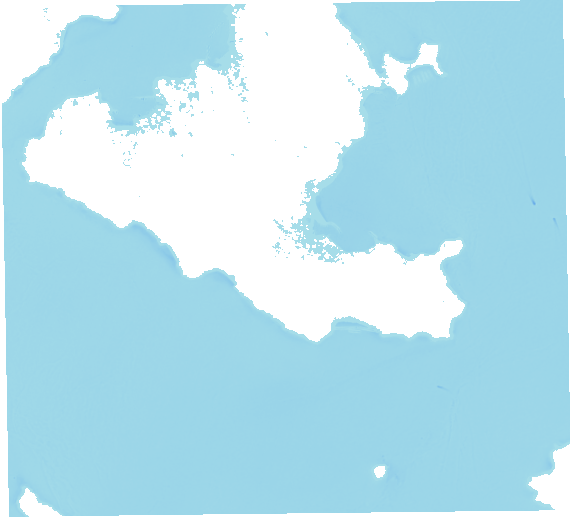

In [9]:
# --- Folium インタラクティブ地図 ---

m = folium.Map(location=KITAGI_CENTER, zoom_start=15, control_scale=True)

# ベースレイヤー: 衛星画像 (Esri)
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
    name="衛星画像 (Esri)",
).add_to(m)

# 国土地理院タイル（参考用）
folium.TileLayer(
    tiles="https://cyberjapandata.gsi.go.jp/xyz/std/{z}/{x}/{y}.png",
    attr="国土地理院",
    name="地理院地図（標準）",
).add_to(m)

# NDWIラスタオーバーレイ（再投影済み EPSG:4326 の範囲を使用）
image_bounds = [
    [reprojected_bounds[1], reprojected_bounds[0]],  # [south, west]
    [reprojected_bounds[3], reprojected_bounds[2]],  # [north, east]
]
ImageOverlay(
    image=f"data:image/png;base64,{img_b64}",
    bounds=image_bounds,
    opacity=0.7,
    name="水域指数（ラスタ）",
    interactive=True,
).add_to(m)

# 水域ポリゴン
folium.GeoJson(
    water_geojson,
    name="水域ポリゴン",
    style_function=lambda x: {
        "fillColor": "#0066ff",
        "color": "#003399",
        "weight": 2,
        "fillOpacity": 0.3,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["area_label"],
        aliases=["面積:"],
    ),
).add_to(m)

# レイヤーコントロール
folium.LayerControl(collapsed=False).add_to(m)

# HTML保存
output_html = f"{OUTPUT_DIR}/exp002_kitagi_water_map.html"
m.save(output_html)
print(f"地図を保存しました: {output_html}")

# GeoJSON保存
output_geojson = f"{OUTPUT_DIR}/exp002_kitagi_water_bodies.geojson"
with open(output_geojson, "w", encoding="utf-8") as f:
    json.dump(water_geojson, f, ensure_ascii=False, indent=2)
print(f"水域GeoJSONを保存しました: {output_geojson}")

# ノートブック内で地図を表示
m

## 7. まとめ

### 出力ファイル

| ファイル | 説明 |
|---------|------|
| `tmp/exp002_kitagi_water_map.html` | インタラクティブ地図（ブラウザで開く） |
| `tmp/exp002_kitagi_water_bodies.geojson` | 水域ポリゴン（GISソフトで利用可能） |
| `tmp/exp002_kitagi_ndwi.tif` | 水域指数 GeoTIFF（NDWI/MNDWI/WaterScore 3バンド） |
| `tmp/exp002_kitagi_water_highlighted.tif` | 水域強調衛星画像 GeoTIFF（RGBA、4バンド） |
| `tmp/exp002_ndwi_static.png` | NDWI・MNDWI・WaterScore 静的画像 |
| `tmp/exp002_ndwi_histogram.png` | NDWI/MNDWIヒストグラム |

### 使い方

- `tmp/exp002_kitagi_water_map.html` をブラウザで開くと、レイヤーを切り替えながら水域を確認できる
- 衛星画像レイヤーに切り替えると、実際の地表面との対応を確認できる
- 水域ポリゴンにマウスオーバーすると、各水域の概算面積が表示される
- GeoTIFFファイルはQGIS等のGISソフトで開き、他のレイヤーと重ね合わせて分析可能

### パラメータの調整

- `NDWI_THRESHOLD` / `MNDWI_THRESHOLD`: 水域判定閾値。負の値にするほど感度が上がる（誤検出も増加）
- `MIN_AREA_M2`: 最小水域面積。小さくすると小規模な水溜りも検出可能
- `SEARCH_DATETIME`: 検索期間。季節による水位変動を考慮して複数時期を試すとよい

### 注意事項

- 海域も水域として検出されるため、丁場跡を特定するには**島内部の水域**に注目する
- 閾値を下げると影や暗い岩肌が誤検出される可能性が高まる。衛星画像レイヤーとの照合を推奨
- Sentinel-2の空間分解能は10mのため、幅10m未満の水域はピクセル混合により検出困難